Experiment about different simulation based inference

At first to test the installation

In [1]:
from sbi.examples.minimal import simple
posterior = simple()
print(posterior)

AttributeError: module 'tensorflow' has no attribute 'io'

In [4]:
import torch
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi

from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,

)

In [5]:
num_dim = 3
prior = utils.BoxUniform(low =-2*torch.ones(num_dim),high = 2 *torch.ones(num_dim))
print(prior)


def simulator(theta):
    return theta + 1.0 +  torch.randn_like(theta)*0.1

BoxUniform(Uniform(low: torch.Size([3]), high: torch.Size([3])), 1)


In [6]:
prior, num_parameters, prior_returns_numpy = process_prior(prior)
print(prior)
print(num_parameters)
print(prior_returns_numpy)

BoxUniform(Uniform(low: torch.Size([3]), high: torch.Size([3])), 1)
3
False


In [7]:
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

In [8]:
inference = SNPE(prior=prior)

In [9]:
theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=1000)

Running 1000 simulations.:   0%|          | 0/1000 [00:00<?, ?it/s]

In [10]:
print(theta.shape)
print(x.shape)

torch.Size([1000, 3])
torch.Size([1000, 3])


In [11]:
inference = inference.append_simulations(theta, x)

In [12]:
density_estimator = inference.train()

 Neural network successfully converged after 72 epochs.

In [13]:
posterior = inference.build_posterior(density_estimator)

In [14]:
theta_true = prior.sample((1,))
# generate our observation
x_obs = simulator(theta_true)

In [15]:
samples = posterior.sample((10000,), x=x_obs)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

In [14]:
import matplotlib.pyplot as plt

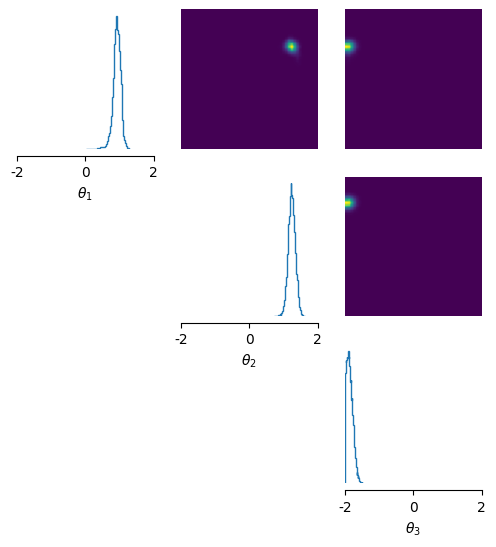

In [15]:
_ = analysis.pairplot(samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(6, 6),labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])
plt.savefig('Likelihood.png')

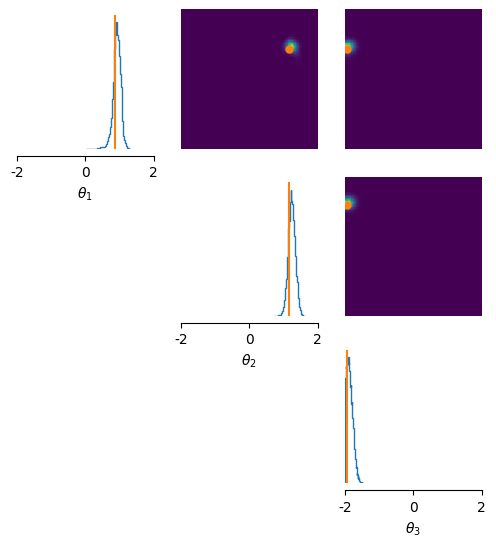

In [16]:
_ = analysis.pairplot(samples, points=theta_true, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(6, 6), labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])
plt.savefig('Likelihood_with_prior.png')

In [17]:
theta_diff = prior.sample((1,))

In [18]:
from sbi.utils.user_input_checks import process_prior, process_simulator, check_sbi_inputs
from sbi.inference import SNPE, simulate_for_sbi

prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)
inference = SNPE(prior)

theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=1000)
density_estimator = inference.append_simulations(theta, x).train()
posterior = inference.build_posterior(density_estimator)

Running 1000 simulations.:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 87 epochs.

Notice, the inference here is not train(). but append_simulations()

In [19]:
import torch

from sbi import analysis as analysis
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

In [20]:
num_dim = 3
prior = utils.BoxUniform(low=-2 * torch.ones(num_dim), high=2 * torch.ones(num_dim))

In [21]:
def linear_gaussian(theta):
    return theta + 1.0 + torch.randn_like(theta) * 0.1

In [22]:
# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(linear_gaussian, prior, prior_returns_numpy)

# Consistency check after making ready for sbi.
check_sbi_inputs(simulator, prior)

In [23]:
inference = SNPE(prior=prior)

In [24]:
theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=2000)

Running 2000 simulations.:   0%|          | 0/2000 [00:00<?, ?it/s]

In [25]:
inference = inference.append_simulations(theta, x)

In [26]:
density_estimator = inference.train()

 Neural network successfully converged after 93 epochs.

In [27]:
posterior = inference.build_posterior(density_estimator)

In [28]:
x_o = torch.zeros(3,)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

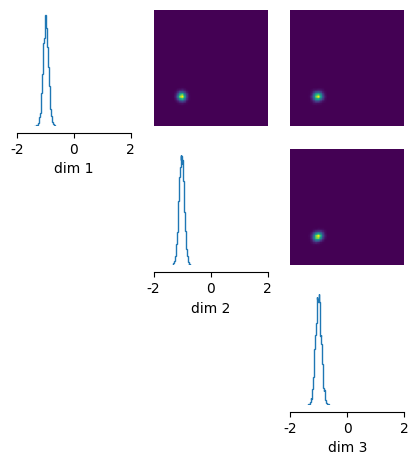

In [29]:
posterior_samples = posterior.sample((10000,), x=x_o)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5)
)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

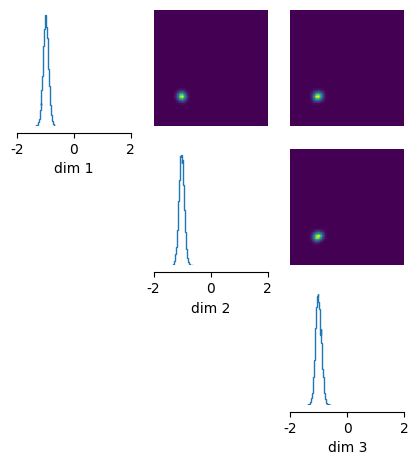

In [30]:
posterior_samples = posterior.sample((10000,), x=x_o)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5)
)

In [31]:
theta_true = prior.sample((1,))
# generate our observation
x_obs = simulator(theta_true)

In [32]:
samples = posterior.sample((10000,), x=x_obs)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

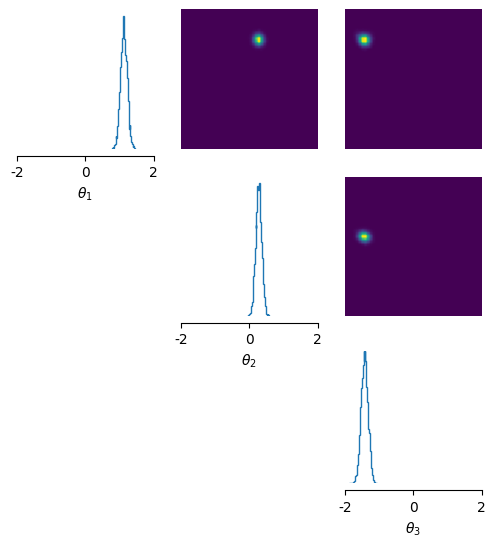

In [33]:
_ = analysis.pairplot(samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(6, 6),labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])

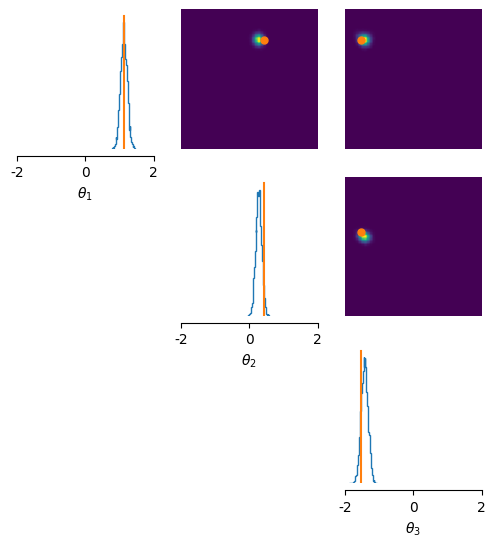

In [34]:
_ = analysis.pairplot(samples, points=theta_true, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(6, 6), labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"])

In [35]:
import torch

from sbi import analysis as analysis
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

In [36]:
num_dim = 3
prior = utils.BoxUniform(low=-2 * torch.ones(num_dim), high=2 * torch.ones(num_dim))

def simulator(theta):
    # linear gaussian
    return theta + 1.0 + torch.randn_like(theta) * 0.1

# Check prior, simulator, consistency
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

In [37]:
# Create inference object. Here, NPE is used.
inference = SNPE(prior=prior)

# generate simulations and pass to the inference object
theta, x = simulate_for_sbi(simulator, proposal=prior, num_simulations=2000)
inference = inference.append_simulations(theta, x)

# train the density estimator and build the posterior
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

Running 2000 simulations.:   0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 69 epochs.

For Amotized inference

In [38]:
# generate the first observation
theta_1 = prior.sample((1,))
x_obs_1 = simulator(theta_1)
# now generate a second observation
theta_2 = prior.sample((1,))
x_obs_2 = simulator(theta_2)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

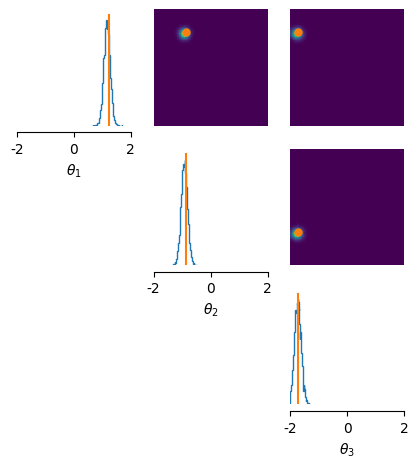

In [39]:
posterior_samples_1 = posterior.sample((10000,), x=x_obs_1)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    points=theta_1 # add ground truth thetas
)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

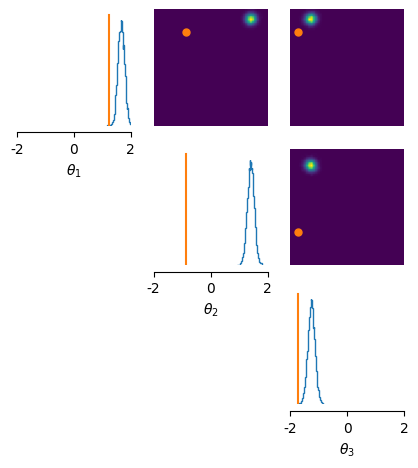

In [40]:
posterior_samples_2 = posterior.sample((10000,), x=x_obs_2)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_2, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    points=theta_1 # add ground truth thetas
)

Fast ε-free Inference of Simulation Models with Bayesian Conditional Density Estimation
by Papamakarios & Murray (NeurIPS 2016)

In [41]:
# Example setup
import torch

from sbi.utils import BoxUniform

# Define the prior
num_dims = 2
num_sims = 1000
num_rounds = 2
prior = BoxUniform(low=torch.zeros(num_dims), high=torch.ones(num_dims))
simulator = lambda theta: theta + torch.randn_like(theta) * 0.1
x_o = torch.tensor([0.5, 0.5])

In [42]:
from sbi.inference import SNPE_A

inference = SNPE_A(prior)
proposal = prior
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    x = simulator(theta)
    _ = inference.append_simulations(theta, x, proposal=proposal).train()
    posterior = inference.build_posterior().set_default_x(x_o)
    proposal = posterior

 Neural network successfully converged after 79 epochs.

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 31 epochs.

In [43]:
import torch

from sbi.analysis import pairplot
from sbi.inference import SNPE, simulate_for_sbi
from sbi.utils import BoxUniform
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

In [44]:
# 2 rounds: first round simulates from the prior, second round simulates parameter set
# that were sampled from the obtained posterior.
num_rounds = 2
num_dim = 3
# The specific observation we want to focus the inference on.
x_o = torch.zeros(num_dim,)
prior = BoxUniform(low=-2 * torch.ones(num_dim), high=2 * torch.ones(num_dim))
simulator = lambda theta: theta + torch.randn_like(theta) * 0.1

# Ensure compliance with sbi's requirements.
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulator = process_simulator(simulator, prior, prior_returns_numpy)
check_sbi_inputs(simulator, prior)

inference = SNPE(prior)

posteriors = []
proposal = prior

for _ in range(num_rounds):
    theta, x = simulate_for_sbi(simulator, proposal, num_simulations=500)

    # In `SNLE` and `SNRE`, you should not pass the `proposal` to
    # `.append_simulations()`
    density_estimator = inference.append_simulations(
        theta, x, proposal=proposal
    ).train()
    posterior = inference.build_posterior(density_estimator)
    posteriors.append(posterior)
    proposal = posterior.set_default_x(x_o)

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 149 epochs.

Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 28 epochs.

In [45]:
def linear_gaussian(theta):
    return theta + 1.0 + torch.randn_like(theta) * 0.1

In [46]:
# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

# Check simulator, returns PyTorch simulator able to simulate batches.
simulator = process_simulator(linear_gaussian, prior, prior_returns_numpy)

# Consistency check after making ready for sbi.
check_sbi_inputs(simulator, prior)

In [47]:
inference = SNPE(prior=prior)

In [48]:
num_rounds = 10
x_o = torch.zeros(
    3,
)

posteriors = []
proposal = prior

for _ in range(num_rounds):
    theta, x = simulate_for_sbi(simulator, proposal, num_simulations=500)
    density_estimator = inference.append_simulations(theta, x, proposal=proposal).train()
    posterior = inference.build_posterior(density_estimator)
    posteriors.append(posterior)
    proposal = posterior.set_default_x(x_o)

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 64 epochs.

Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 24 epochs.

...

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 38 epochs.

Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 39 epochs.

In [49]:
print(proposal)

Posterior conditional density p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [50]:
print(prior)

BoxUniform(Uniform(low: torch.Size([3]), high: torch.Size([3])), 1)


Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

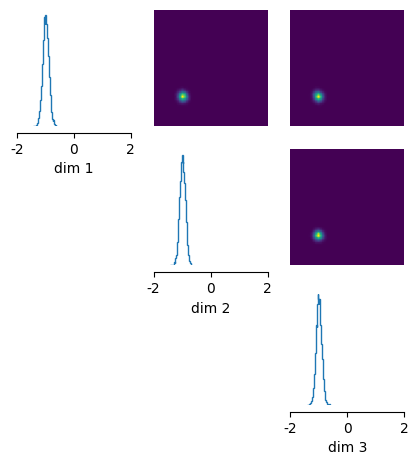

In [51]:
posterior_samples = posterior.sample((10000,), x=x_o)

# plot posterior samples
fig, ax = pairplot(
    posterior_samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5)
)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

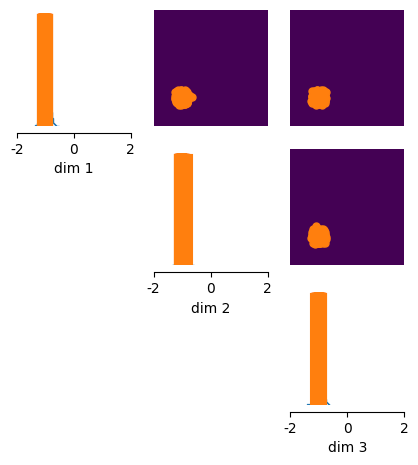

In [52]:
posterior_samples = posterior.sample((10000,), x=x_o)

# plot posterior samples
fig, ax = pairplot(
    posterior_samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),points=theta
)

In [60]:
import torch

from sbi.inference import SNLE

# dummy Gaussian simulator for demonstration
num_dim = 2
prior = torch.distributions.MultivariateNormal(torch.zeros(num_dim), torch.eye(num_dim))
theta = prior.sample((1000,))
x = theta + torch.randn((1000, num_dim))
x_o = torch.randn((1, num_dim))

inference = SNLE(prior=prior, show_progress_bars=False)
likelihood_estimator = inference.append_simulations(theta, x).train()

 Neural network successfully converged after 116 epochs.

In [61]:
# Sampling with MCMC
sampling_algorithm = "mcmc"
mcmc_method = "slice_np"  # or nuts, or hmc
posterior = inference.build_posterior(sample_with=sampling_algorithm,
                                      mcmc_method=mcmc_method)

# Sampling with variational inference
sampling_algorithm = "vi"
vi_method = "rKL"  # or fKL
posterior = inference.build_posterior(sample_with=sampling_algorithm,
                                      vi_method=vi_method)
# Unlike other methods, vi needs a training step for every observation.
posterior = posterior.set_default_x(x_o).train()

# Sampling with rejection sampling
sampling_algorithm = "rejection"
posterior = inference.build_posterior(sample_with=sampling_algorithm)

  0%|          | 0/2000 [00:00<?, ?it/s]


Converged with loss: 2.64
Quality Score: -0.043 	 Good: Smaller than 0.5  Bad: Larger than 1.0 	         NOTE: Less sensitive to mode collapse.


In [62]:
# Example setup
import torch

from sbi.utils import BoxUniform

# Define the prior
num_dims = 2
num_sims = 1000
num_rounds = 2
prior = BoxUniform(low=torch.zeros(num_dims), high=torch.ones(num_dims))
simulator = lambda theta: theta + torch.randn_like(theta) * 0.1
x_o = torch.tensor([0.5, 0.5])

In [63]:
from sbi.inference import SNPE_A

inference = SNPE_A(prior)
proposal = prior
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    x = simulator(theta)
    _ = inference.append_simulations(theta, x, proposal=proposal).train()
    posterior = inference.build_posterior().set_default_x(x_o)
    proposal = posterior

 Neural network successfully converged after 75 epochs.

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 29 epochs.

In [64]:
print(posterior)

Posterior conditional density p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


In [65]:
from sbi.inference import SNLE

inference = SNLE(prior)
proposal = prior
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    x = simulator(theta)
    _ = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(mcmc_method="slice_np_vectorized",
                                          mcmc_parameters={"num_chains": 20,
                                                           "thin": 5})
    proposal = posterior.set_default_x(x_o)

 Neural network successfully converged after 69 epochs.

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

 Neural network successfully converged after 79 epochs.

In [66]:
print(posterior)

Posterior conditional density p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().


In [67]:
print(proposal)

Posterior conditional density p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().


In [68]:
# Example setup
import torch

from sbi.utils import BoxUniform

# Define the prior
num_dims = 2
num_sims = 1000
num_rounds = 2
prior = BoxUniform(low=torch.zeros(num_dims), high=torch.ones(num_dims))
simulator = lambda theta: theta + torch.randn_like(theta) * 0.1
x_o = torch.tensor([0.5, 0.5])

In [69]:
from sbi.inference import SNPE_A

inference = SNPE_A(prior)
proposal = prior
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    x = simulator(theta)
    _ = inference.append_simulations(theta, x, proposal=proposal).train()
    posterior = inference.build_posterior().set_default_x(x_o)
    proposal = posterior

 Neural network successfully converged after 51 epochs.

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 26 epochs.

In [70]:
from sbi.inference import SNPE_A

inference = SNPE_A(prior)
proposal = prior
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    x = simulator(theta)
    _ = inference.append_simulations(theta, x, proposal=proposal).train()
    #posterior = inference.build_posterior().set_default_x(x_o)
    proposal = posterior

 Neural network successfully converged after 36 epochs.

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 21 epochs.

In [71]:
from sbi.inference import SNPE_A

inference = SNPE_A(prior)
proposal = prior
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    x = simulator(theta)
    _ = inference.append_simulations(theta, x, proposal=proposal).train()
    posterior = inference.build_posterior().set_default_x(x_o)
    proposal = posterior

 Neural network successfully converged after 49 epochs.

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 31 epochs.

In [72]:
from sbi.inference import SNPE_A

inference = SNPE_A(prior)
proposal = prior
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    x = simulator(theta)
    _ = inference.append_simulations(theta, x, proposal=proposal).train()
    posterior = inference.build_posterior().set_default_x(x_o)
    proposal = posterior

 Neural network successfully converged after 48 epochs.

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

 Neural network successfully converged after 29 epochs.

In [73]:
# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch

from sbi import analysis as analysis

# sbi
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

In [74]:
# remove top and right axis from plots
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False

In [75]:
from HH_helper_functions import syn_current

# current, onset time of stimulation, offset time of stimulation, time step, time, area of some
I_inj, t_on, t_off, dt, t, A_soma = syn_current()

ModuleNotFoundError: No module named 'HH_helper_functions'

In [ ]:
from HH_helper_functions import HHsimulator

In [ ]:
def run_HH_model(params):

    params = np.asarray(params)

    # input current, time step
    I_inj, t_on, t_off, dt, t, A_soma = syn_current()

    t = np.arange(0, len(I_inj), 1) * dt

    # initial voltage V0
    initial_voltage = -70

    voltage_trace = HHsimulator(initial_voltage, params.reshape(1, -1), dt, t, I_inj)

    return dict(data=voltage_trace.reshape(-1), time=t, dt=dt, I_inj=I_inj.reshape(-1))

In [ ]:
# three sets of (g_Na, g_K)
params = np.array([[50.0, 1.0], [4.0, 1.5], [20.0, 15.0]])

num_samples = len(params[:, 0])
sim_samples = np.zeros((num_samples, len(I_inj)))
for i in range(num_samples):
    sim_samples[i, :] = run_HH_model(params=params[i, :])["data"]

In [ ]:
# colors for traces
col_min = 2
num_colors = num_samples + col_min
cm1 = mpl.cm.Blues
col1 = [cm1(1.0 * i / num_colors) for i in range(col_min, num_colors)]

fig = plt.figure(figsize=(7, 5))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[4, 1])
ax = plt.subplot(gs[0])
# plot the three voltage traces for different parameter sets
for i in range(num_samples):
    plt.plot(t, sim_samples[i, :], color=col1[i], lw=2)
plt.ylabel("voltage (mV)")
ax.set_xticks([])
ax.set_yticks([-80, -20, 40])

# plot the injected current
ax = plt.subplot(gs[1])
plt.plot(t, I_inj * A_soma * 1e3, "k", lw=2)
plt.xlabel("time (ms)")
plt.ylabel("input (nA)")

ax.set_xticks([0, max(t) / 2, max(t)])
ax.set_yticks([0, 1.1 * np.max(I_inj * A_soma * 1e3)])
ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
plt.savefig('Different_c.png')
plt.show()

In [ ]:
from HH_helper_functions import calculate_summary_statistics

In [ ]:
def simulation_wrapper(params):
    """
    Returns summary statistics from conductance values in `params`.

    Summarizes the output of the HH simulator and converts it to `torch.Tensor`.
    """
    obs = run_HH_model(params)
    summstats = torch.as_tensor(calculate_summary_statistics(obs))
    return summstats

In [ ]:
prior_min = [0.5, 1e-4]
prior_max = [80.0, 15.0]
prior = utils.torchutils.BoxUniform(
    low=torch.as_tensor(prior_min), high=torch.as_tensor(prior_max)
)

# Check prior, simulator, consistency
prior, num_parameters, prior_returns_numpy = process_prior(prior)
simulation_wrapper = process_simulator(simulation_wrapper, prior, prior_returns_numpy)
check_sbi_inputs(simulation_wrapper, prior)

In [ ]:
# Create inference object. Here, NPE is used.
inference = SNPE(prior=prior)

# generate simulations and pass to the inference object
theta, x = simulate_for_sbi(simulation_wrapper, proposal=prior,
                             num_simulations=300, num_workers=4)
inference = inference.append_simulations(theta, x)

# train the density estimator and build the posterior
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

In [ ]:
# true parameters and respective labels
true_params = np.array([50.0, 5.0])
labels_params = [r"$g_{Na}$", r"$g_{K}$"]

In [ ]:
observation_trace = run_HH_model(true_params)
observation_summary_statistics = calculate_summary_statistics(observation_trace)

In [ ]:
fig = plt.figure(figsize=(7, 5))
gs = mpl.gridspec.GridSpec(2, 1, height_ratios=[4, 1])
ax = plt.subplot(gs[0])
plt.plot(observation_trace["time"], observation_trace["data"])
plt.ylabel("voltage (mV)")
plt.title("observed data")
plt.setp(ax, xticks=[], yticks=[-80, -20, 40])

ax = plt.subplot(gs[1])
plt.plot(observation_trace["time"], I_inj * A_soma * 1e3, "k", lw=2)
plt.xlabel("time (ms)")
plt.ylabel("input (nA)")

ax.set_xticks([0, max(observation_trace["time"]) / 2, max(observation_trace["time"])])
ax.set_yticks([0, 1.1 * np.max(I_inj * A_soma * 1e3)])
ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
plt.savefig('Observe.png')

In [ ]:
samples = posterior.sample((10000,), x=observation_summary_statistics)

In [ ]:
fig, axes = analysis.pairplot(
    samples,
    limits=[[0.5, 80], [1e-4, 15.0]],
    ticks=[[0.5, 80], [1e-4, 15.0]],
    figsize=(5, 5),
    points=true_params,
    points_offdiag={"markersize": 6},
    points_colors="r",
    labels=labels_params,
);
plt.savefig('Final.png')

In [ ]:
# Draw a sample from the posterior and convert to numpy for plotting.
posterior_sample = posterior.sample((1,), x=observation_summary_statistics).numpy()

In [ ]:
fig = plt.figure(figsize=(7, 5))

# plot observation
t = observation_trace["time"]
y_obs = observation_trace["data"]
plt.plot(t, y_obs, lw=2, label="observation")

# simulate and plot samples
x = run_HH_model(posterior_sample)
plt.plot(t, x["data"], "--", lw=2, label="posterior sample")

plt.xlabel("time (ms)")
plt.ylabel("voltage (mV)")

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], bbox_to_anchor=(1.3, 1), loc="upper right")

ax.set_xticks([0, 60, 120])
ax.set_yticks([-80, -20, 40]);
plt.savefig('Compare.png')

In [ ]:
using IJulia